# SuperMockLoad — quickstart

Load a SuperMock skypatch, look at the basics, and make a couple of plots.
The package ships the observational comparison data; point it at the synthetic
catalogs via `SUPERMOCK_DATA` or `root=`.

In [1]:
import os
# Set this to wherever the SuperMock patch files live:
os.environ['SUPERMOCK_DATA'] = '/lcrc/project/cosmo_ai/nramachandra/Projects/SPHEREx/Mocks_v3_data'

In [2]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from supermockload import SuperMock, available_patches, plots, observations

In [3]:
available_patches()

[3]

### Load one patch
`downsample=` keeps a random subset (fast, low memory). Drop it for all rows.

In [9]:
sm = SuperMock(3, downsample=300_000)
sm

[SuperMock]   patch 3: 300,000 rows (of 35,996,146)
[SuperMock] ready: 300,000 galaxies, patches [3], downsampled to 300,000 (photometry/luminosities/SEDs load on demand)


SuperMock(patches=[3], n=300,000, seds=False)

In [19]:
sm

SuperMock(patches=[3], n=300,000, seds=False)

In [5]:
print('footprint  :', round(sm.area_deg2, 1), 'deg^2')
print('N galaxies :', f'{sm.n:,}  (downsampled)')
print('z median   :', round(np.median(sm.redshift), 3))
print('logM* median (obs-epoch):', round(np.median(sm.logM_zobs), 2))

footprint  : 233.9 deg^2
N galaxies : 300,000  (downsampled)
z median   : 1.742
logM* median (obs-epoch): 9.46


### Photometry & luminosities
Surveys: `LSST WISE SPHEREx COSMOS LEGACYSURVEY 2MASS F784` (all AB).

In [6]:
mi = sm.mag('LSST', 'i')          # one band
print('LSST i median :', round(np.nanmedian(mi), 2))
print('SPHEREx matrix:', sm.survey('SPHEREx').shape, '| labels e.g.', sm.bands('SPHEREx')[:3])
print('M_r (rest)    :', round(np.nanmedian(sm.abs_mag('SDSS', 'r')), 2))

LSST i median : 25.99
SPHEREx matrix: (300000, 102) | labels e.g. ['SPHEREx_band1_ch16', 'SPHEREx_band1_ch14', 'SPHEREx_band1_ch11']
M_r (rest)    : -20.22


### A couple of plots vs observations

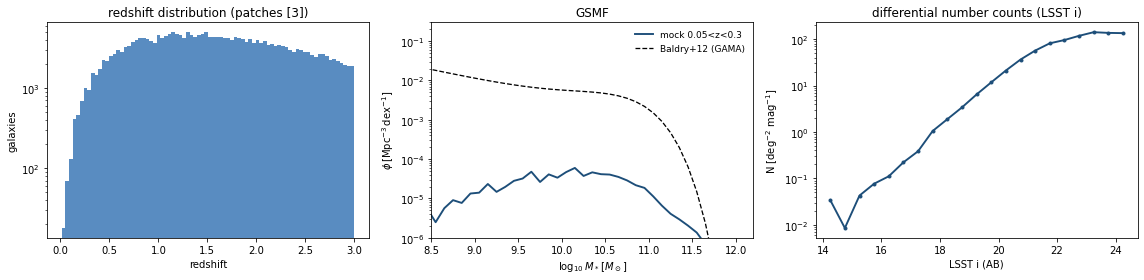

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
plots.redshift_distribution(sm, ax=ax[0])
plots.gsmf(sm, ax=ax[1])
plots.number_counts(sm, ax=ax[2], survey='LSST', band='i')
fig.tight_layout()

### Fast repeat loads: snapshots

The catalog/photometry files are gzip-compressed, so the first read is slow.
Snapshot a downsampled view to an uncompressed file that reloads instantly.

In [8]:
rows = sm.sample(2000)                                  # for a stored SED subset
# needs seds=True to store SEDs; here we snapshot catalog+photometry only:
sm.save('patch3_300k.snapshot.h5', surveys=('LSST', 'WISE'))
sm2 = SuperMock.from_file('patch3_300k.snapshot.h5')    # instant
sm2

[SuperMock] snapshot -> patch3_300k.snapshot.h5 (52 MB, surveys=['LSST', 'WISE'])
[SuperMock] loaded snapshot patch3_300k.snapshot.h5: 300,000 galaxies, surveys=['LSST', 'WISE']


SuperMock(patches=[3], n=300,000, seds=False)